# Whole code for the Sentiment analysis between Fear and Greed Sentiment Data

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## Loading Datasets

In [2]:
historical_data = pd.read_csv("historical_data.csv")
fear_greed = pd.read_csv("fear_greed_index.csv")

Historical Shape: (211224, 16)
Fear Greed Shape: (2644, 4)


In [ ]:
print("Historical Shape:", historical_data.shape)

In [ ]:
print("Fear Greed Shape:", fear_greed.shape)

## Understanding or getting the various information of the dataset

In [3]:
print("\nHistorical Data Info")
print(historical_data.info())


Historical Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dty

In [ ]:
print("\nFear Greed Info")
print(fear_greed.info())

In [4]:
print("\nMissing Values")
print(historical_data.isnull().sum())


Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear Greed Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
print("\nFear Greed Missing Values")
print(fear_greed.isnull().sum())

In [5]:
print("\nHistorical Summary")
print(historical_data.describe(include="all"))


Historical Summary
                                           Account    Coin  Execution Price  \
count                                       211224  211224    211224.000000   
unique                                          32     246              NaN   
top     0xbee1707d6b44d4d52bfe19e41f8a828645437aab    HYPE              NaN   
freq                                         40184   68005              NaN   
mean                                           NaN     NaN     11414.723350   
std                                            NaN     NaN     29447.654868   
min                                            NaN     NaN         0.000005   
25%                                            NaN     NaN         4.854700   
50%                                            NaN     NaN        18.280000   
75%                                            NaN     NaN       101.580000   
max                                            NaN     NaN    109004.000000   

         Size Tokens      Size 

## Data Proprocessing

### Converting TimeStamp

In [6]:
historical_data["Date"] = pd.to_datetime(
    historical_data["Timestamp"],
    unit="ms"
).dt.date

fear_greed["Date"] = pd.to_datetime(
    fear_greed["date"]
).dt.date

### Removing duplicate data

In [7]:
historical_data.drop_duplicates(inplace=True)
fear_greed.drop_duplicates(inplace=True)

### Handling Missing Values

In [8]:
historical_data.fillna(method="ffill", inplace=True)
fear_greed.fillna(method="ffill", inplace=True)

## Merging the both datasets

In [9]:
df = pd.merge(
    historical_data,
    fear_greed[
        ["Date", "value", "classification"]
    ],
    on="Date",
    how="left"
)

print("Merged Shape:", df.shape)

Merged Shape: (211224, 19)


## Doing Feature Engineering

### Taking out Target columns/values

In [10]:
df["Profit_Flag"] = (
    df["Closed PnL"] > 0
).astype(int)

### Converting Trade size into categorical values

In [11]:
df["Trade_Size_Category"] = pd.cut(
    df["Size USD"],
    bins=[0,1000,10000,50000,np.inf],
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)

### Daily Trading Value

In [12]:
daily_volume = (
    df.groupby("Date")["Size USD"]
    .sum()
    .reset_index()
)

daily_volume.columns = [
    "Date",
    "Daily_Trading_Volume"
]

df = pd.merge(
    df,
    daily_volume,
    on="Date",
    how="left"
)

### Time Featuring

In [13]:
timestamp_dt = pd.to_datetime(
    df["Timestamp"],
    unit="ms"
)

df["Trade_Hour"] = timestamp_dt.dt.hour
df["Trade_DayOfWeek"] = timestamp_dt.dt.dayofweek
df["Trade_Month"] = timestamp_dt.dt.month

### Additional Features

In [14]:
df["Fee_Percent"] = (
    df["Fee"] /
    (df["Size USD"] + 1)
)

df["PnL_to_Size"] = (
    df["Closed PnL"] /
    (df["Size USD"] + 1)
)

df["value"] = pd.to_numeric(
    df["value"],
    errors="coerce"
)

## Exploratory Data Analysis

### Target Distribution

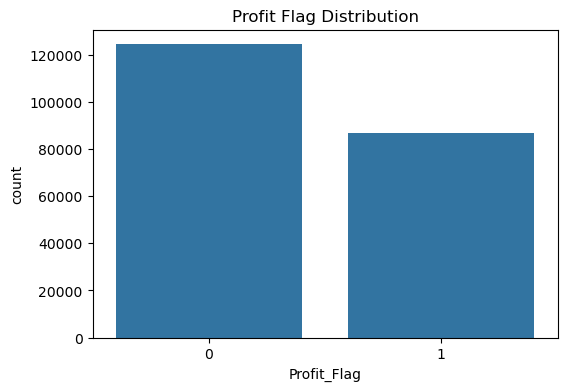

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Profit_Flag",
    data=df
)

plt.title("Profit Flag Distribution")
plt.show()

### Fear Greed Distribution

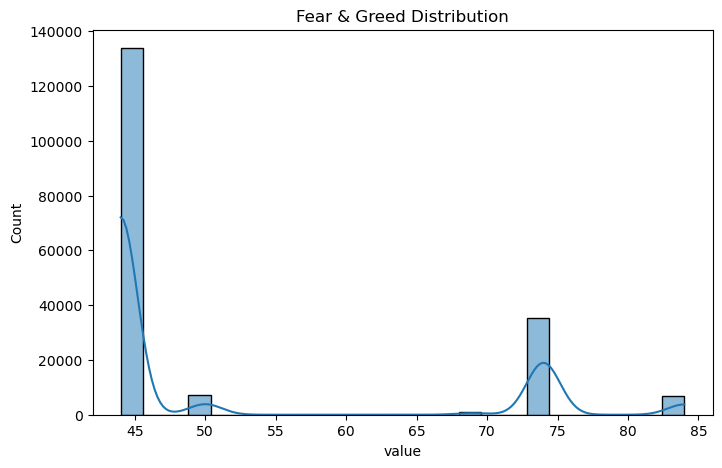

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["value"],
    bins=25,
    kde=True
)

plt.title("Fear & Greed Distribution")
plt.show()

### Sentiment vs Profitability

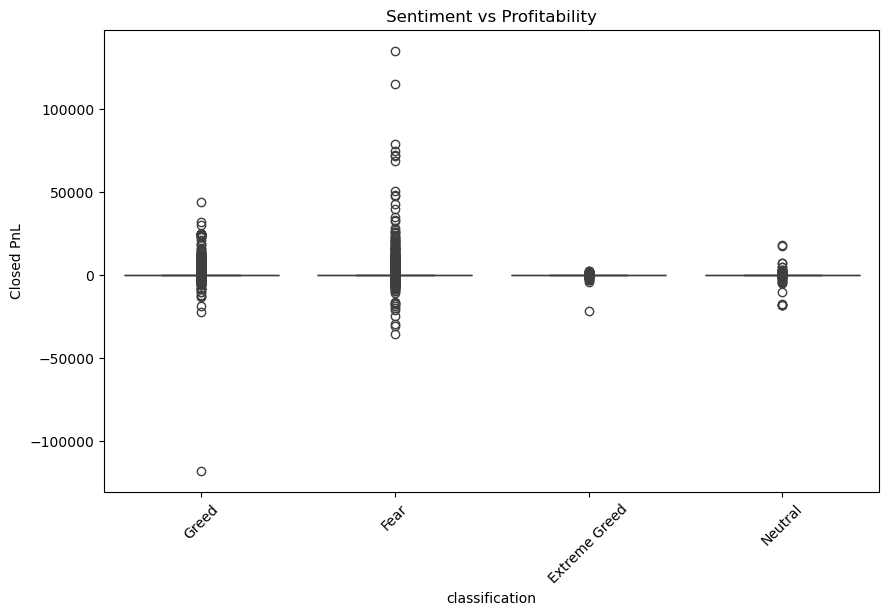

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=df
)

plt.xticks(rotation=45)
plt.title(
    "Sentiment vs Profitability"
)

plt.show()

### Trade Size vs Profit

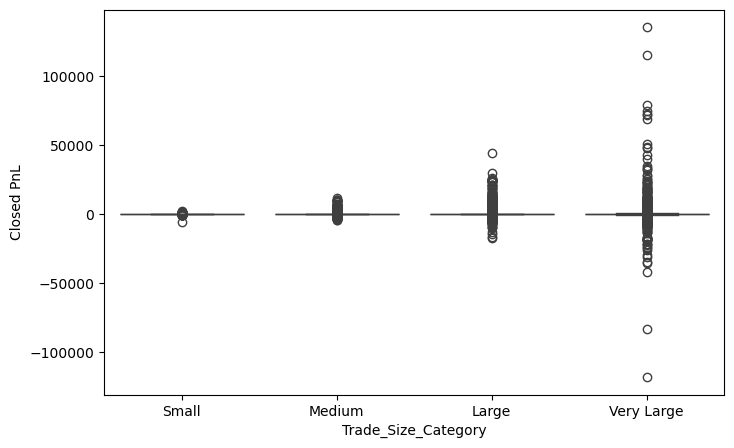

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Trade_Size_Category",
    y="Closed PnL",
    data=df
)

plt.show()

## Prepare Modeling Dataset

### Remove Leakage Columns

In [19]:
drop_cols = [

    "Account",
    "Transaction Hash",
    "Order ID",
    "Trade ID",

    "Timestamp",
    "Timestamp IST",
    "Date",

    "Closed PnL"
]

model_df = df.drop(
    columns=drop_cols,
    errors="ignore"
)

### One Hot Encoding

In [20]:
categorical_cols = [

    "Coin",
    "Side",
    "Direction",
    "classification",
    "Trade_Size_Category"
]

model_df = pd.get_dummies(
    model_df,
    columns=categorical_cols,
    drop_first=True
)

### Handling Missing Values

In [21]:
model_df.fillna(
    model_df.median(numeric_only=True),
    inplace=True
)

model_df.fillna(0, inplace=True)

## Correlation Analysis

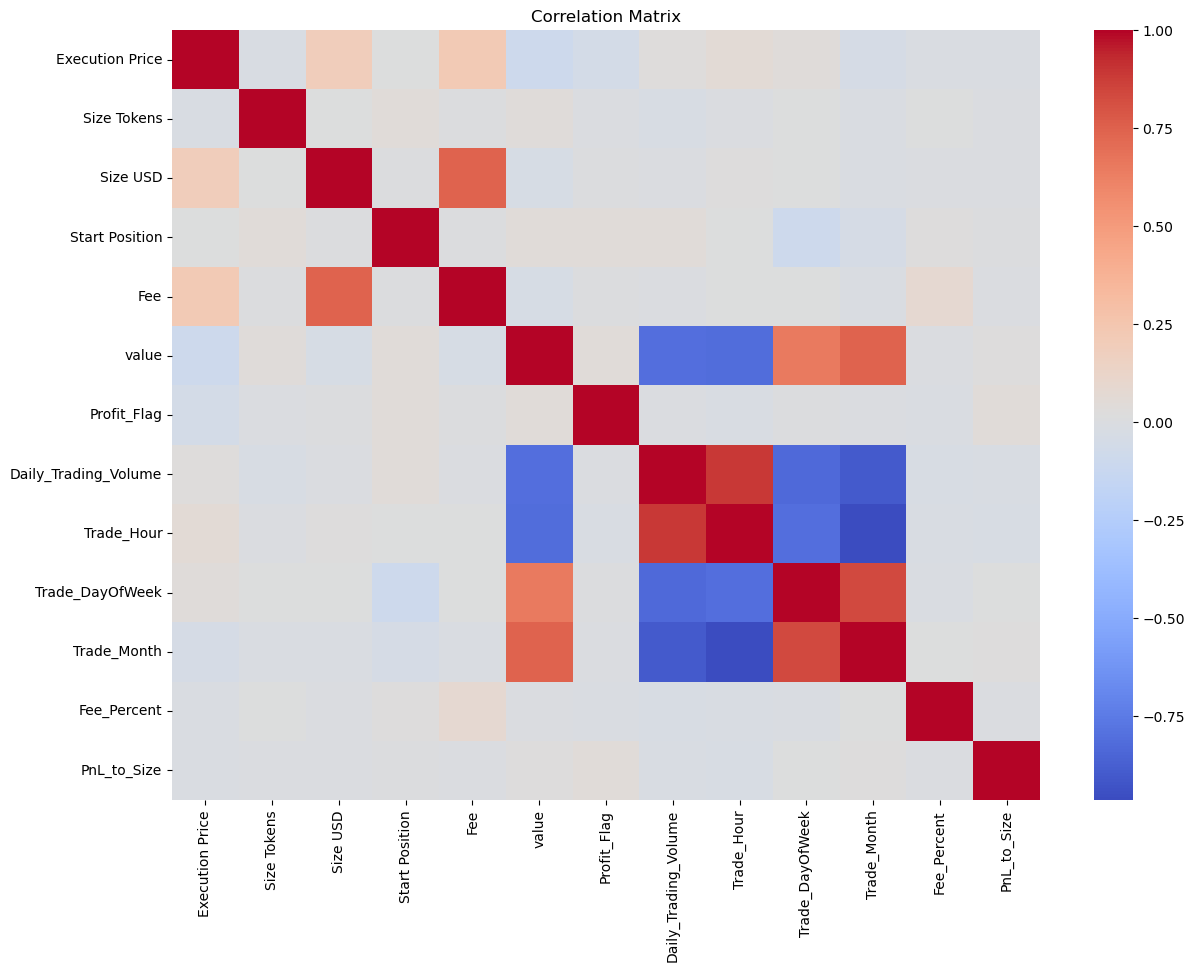

In [22]:
numeric_df = model_df.select_dtypes(
    include=np.number
)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Train Test Split

In [23]:
X = model_df.drop(
    "Profit_Flag",
    axis=1
)

y = model_df["Profit_Flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Feature Scaling
### (Logistic Regression only)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [25]:
lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

## Decision Tree

In [26]:
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

## Random Forest

In [27]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

## Evaluation Function

In [28]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_pred
    )

    print("\n")
    print("="*50)
    print(model_name)
    print("="*50)

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.show()

    return [
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

## Evaluate Models



Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     24871
           1       0.92      1.00      0.96     17374

    accuracy                           0.97     42245
   macro avg       0.96      0.97      0.96     42245
weighted avg       0.97      0.97      0.97     42245



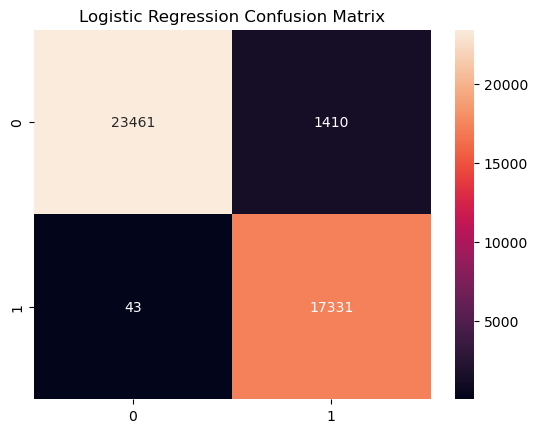



Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24871
           1       1.00      1.00      1.00     17374

    accuracy                           1.00     42245
   macro avg       1.00      1.00      1.00     42245
weighted avg       1.00      1.00      1.00     42245



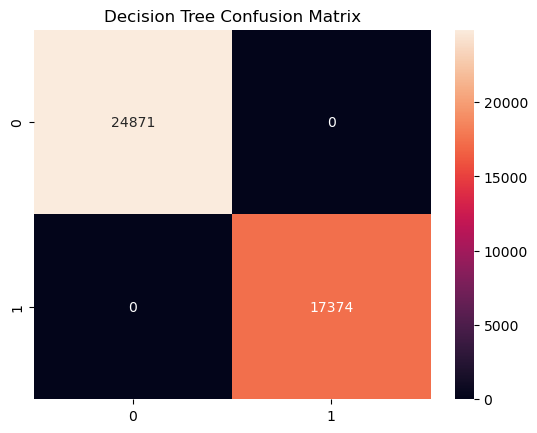



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24871
           1       1.00      1.00      1.00     17374

    accuracy                           1.00     42245
   macro avg       1.00      1.00      1.00     42245
weighted avg       1.00      1.00      1.00     42245



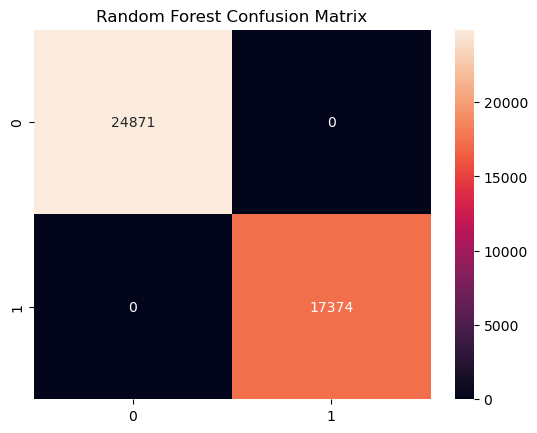

In [29]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

## Model Compariosn

In [30]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
1        Decision Tree  1.000000   1.000000  1.000000  1.000000  1.000000
2        Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000
0  Logistic Regression  0.965605   0.924764  0.997525  0.959767  0.970416


## Feature Importance (Random Forest)

In [31]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(
    importance_df.head(20)
)

                   Feature  Importance
12             PnL_to_Size    0.447846
264    Direction_Open Long    0.092078
260   Direction_Close Long    0.092073
265   Direction_Open Short    0.071869
258              Side_SELL    0.057688
3           Start Position    0.055223
261  Direction_Close Short    0.053217
266         Direction_Sell    0.023356
259          Direction_Buy    0.020842
11             Fee_Percent    0.014288
0          Execution Price    0.013639
16               Coin_@107    0.010919
5                      Fee    0.006574
1              Size Tokens    0.004440
2                 Size USD    0.003037
4                  Crossed    0.002525
10             Trade_Month    0.002157
8               Trade_Hour    0.002099
7     Daily_Trading_Volume    0.002060
149              Coin_HYPE    0.002036


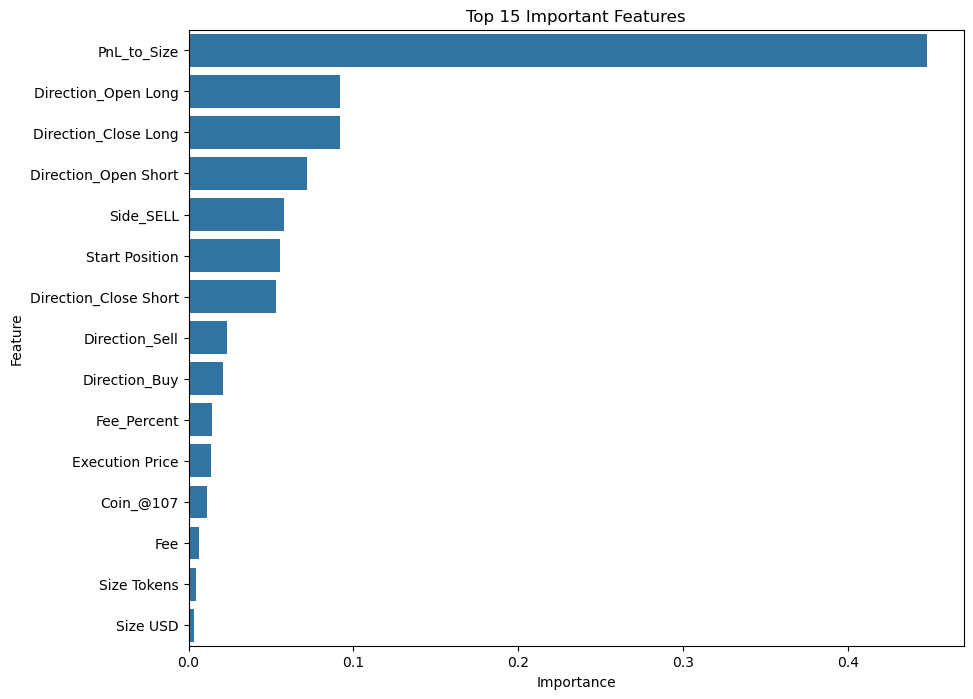

In [32]:
plt.figure(figsize=(10,8))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance_df.head(15)
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

## Business Insights

In [33]:
best_model = results_df.iloc[0]["Model"]

print("\n" + "="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"""
Best Model: {best_model}

Key Findings:

1. Trader profitability can be predicted using
   trade characteristics and market sentiment.

2. Fear & Greed Index contributes to
   profitability prediction.

3. Trade size, trading volume, fees,
   and sentiment are major factors.

4. Feature importance identifies the
   strongest drivers of profitable trades.

5. The model can be used for:
   - Trade risk assessment
   - Profitability prediction
   - Strategy optimization
   - Sentiment-aware trading decisions
""")


BUSINESS INSIGHTS

Best Model: Decision Tree

Key Findings:

1. Trader profitability can be predicted using
   trade characteristics and market sentiment.

2. Fear & Greed Index contributes to
   profitability prediction.

3. Trade size, trading volume, fees,
   and sentiment are major factors.

4. Feature importance identifies the
   strongest drivers of profitable trades.

5. The model can be used for:
   - Trade risk assessment
   - Profitability prediction
   - Strategy optimization
   - Sentiment-aware trading decisions



### Sentiment vs Profitability

In [35]:
sentiment_profit = df.groupby(
    "classification"
)["Closed PnL"].mean()

print(sentiment_profit)

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


### Win rate by sentiment

In [36]:
win_rate = df.groupby(
    "classification"
)["Profit_Flag"].mean()*100

print(win_rate)

classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: Profit_Flag, dtype: float64


### Trading volume vs sentiment

In [37]:
volume_analysis = df.groupby(
    "classification"
)["Size USD"].mean()

print(volume_analysis)

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


### Risk Taking Behavior

In [38]:
df.groupby(
    "classification"
)["Fee"].mean()

classification
Extreme Greed    0.978567
Fear             1.083267
Greed            0.670562
Neutral          1.224461
Name: Fee, dtype: float64

### Important Business KPIs

In [39]:
# Average Profit
df.groupby("classification")["Closed PnL"].mean()

# Median Profit
df.groupby("classification")["Closed PnL"].median()

# Total Profit
df.groupby("classification")["Closed PnL"].sum()

# Win Rate
df.groupby("classification")["Profit_Flag"].mean()

# Average Trade Size
df.groupby("classification")["Size USD"].mean()

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

## Actionable Trading Strategies
**Strategy A: Sentiment-Based Position Sizing**

_IF_:

    Greed -> High Win Rate
    Fear -> Low Win Rate
    
_Then_:

    Increase position size during Greed
    Reduce position size during Fear

**Strategy B: Contrarian Strategy**

_If_:

    Extreme Fear produces the highest future profits
    
_Then_:

    Buy during Extreme Fear
    Take profits during Extreme Greed

**Strategy C: Risk Management**

_If_:

    Losses become larger during Extreme Greed
    
_Then_:
    Use tighter stop-losses during euphoric markets

### Relationship Between Trader Performance and Market Sentiment

**In our dataset, we have the Fear & Greed index that has sentiment categories like:**
    * Extreme Fear
    * Fear
    * Neutral
    * Greed
    * Extreme Greed
    
**In our trading dataset, we have:**
    * Closed PnL (Profit/Loss)
    * Trade Size
    * Buy/Sell side
    * Direction
    * Fees
    * Trading volume

#### From this data, we can get

1. Do traders make more profit during Greed periods?
> Business Insight - We need to measure the average PnL sentiment

2. Are losses larger during Extreme Fear?
> Business Insight - We need to do Risk Analysis

3. Does trading volume increase during Greed?
> Business Insight - We need to do Behavioral Analysis

4. Are traders more aggressive during Extreme Greed?
> Business Insight - We need to do Position sizing analysis

5. Which sentiment produces the highest win rate?
> Business Insight - Strategy optimization